# HARLF Backtesting & Results Analysis

This notebook performs comprehensive backtesting of the trained HARLF system on out-of-sample test data.

In [1]:
# Cell 1: Imports and Data Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pickle
import dill
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, SAC, DDPG, TD3
from utile import *

print("Loading data and trained models...")

# Load data
test_prices = pd.read_csv('outputs/test_prices.csv', index_col=0, parse_dates=True)
test_features = pd.read_csv('outputs/test_features.csv', index_col=0, parse_dates=True)
test_tech_indicators = pd.read_csv('outputs/test_tech_indicators.csv', index_col=0, parse_dates=True)
ASSETS = pd.read_csv('outputs/assets.csv', index_col=0).to_dict()['name']

print(f"Data loaded:")
print(f"  Test prices: {test_prices.shape}")
print(f"  Test features (NLP): {test_features.shape}")
print(f"  Test tech indicators: {test_tech_indicators.shape}")
print(f"  Assets: {len(ASSETS)}")

# Load base agents
def load_base_agents():
    """Load base agents from saved models"""
    try:
        with open('models/base_agent_names.pkl', 'rb') as f:
            agent_names = pickle.load(f)
        
        loaded_agents = {}
        for agent_name in agent_names:
            try:
                if 'PPO' in agent_name:
                    agent = PPO.load(f'models/base_agent_{agent_name}')
                elif 'SAC' in agent_name:
                    agent = SAC.load(f'models/base_agent_{agent_name}')
                elif 'DDPG' in agent_name:
                    agent = DDPG.load(f'models/base_agent_{agent_name}')
                elif 'TD3' in agent_name:
                    agent = TD3.load(f'models/base_agent_{agent_name}')
                
                loaded_agents[agent_name] = agent
                print(f"  Loaded {agent_name}")
            except Exception as e:
                print(f"  Failed to load {agent_name}: {e}")
        
        return loaded_agents
    except Exception as e:
        print(f"Error loading base agents: {e}")
        return {}

base_agents = load_base_agents()
print(f"{len(base_agents)} base agents loaded")

# Load meta and super agents (with robust error handling)
try:
    print("Attempting to load hierarchical agents...")
    with open('models/model_info.pkl', 'rb') as f:
        model_info = pickle.load(f)
    
    with open('models/model_classes.pkl', 'rb') as f:
        model_classes = dill.load(f)
    
    MetaAgent = model_classes['MetaAgent']
    SuperAgent = model_classes['SuperAgent']
    
    # Recreate meta-agents
    meta_agent_data = MetaAgent(model_info['data_input_dim'], model_info['n_assets'])
    meta_agent_data.load_state_dict(torch.load('models/meta_agent_data.pth', map_location='cpu'))
    meta_agent_data.eval()
    
    meta_agent_nlp = MetaAgent(model_info['nlp_input_dim'], model_info['n_assets'])
    meta_agent_nlp.load_state_dict(torch.load('models/meta_agent_nlp.pth', map_location='cpu'))
    meta_agent_nlp.eval()
    
    # Recreate super-agent
    super_agent = SuperAgent(model_info['n_assets'])
    super_agent.load_state_dict(torch.load('models/super_agent.pth', map_location='cpu'))
    super_agent.eval()
    
    print("Meta-agents and super-agent loaded successfully!")
    
except Exception as e:
    print(f"Warning: Could not load meta/super agents: {e}")
    print("Will use ensemble of base agents only (still effective!)")
    meta_agent_data = None
    meta_agent_nlp = None
    super_agent = None

print(f"Test period: {len(test_prices)} months")
print(f"Base agents: {len(base_agents)}")
print("\n=== Setup Complete ===\n")


Loading data and trained models...
Data loaded:
  Test prices: (57, 17)
  Test features (NLP): (57, 34)
  Test tech indicators: (57, 221)
  Assets: 17
  Loaded PPO_data
  Loaded SAC_data
  Loaded PPO_nlp
  Loaded SAC_nlp
4 base agents loaded
Attempting to load hierarchical agents...
Meta-agents and super-agent loaded successfully!
Test period: 57 months
Base agents: 4

=== Setup Complete ===



In [2]:
# Cell 2: Backtesting Function
def backtest_harlf_updated(super_agent, meta_agent_data, meta_agent_nlp, base_agents,
                          test_prices, test_features, test_tech_indicators, initial_capital=100000):
    """
    Backtest the complete HARLF system on out-of-sample data
    """
    print("Running HARLF backtest on test data...")
    
    # Initialize tracking variables
    portfolio_values = [initial_capital]
    portfolio_weights_history = []
    monthly_returns = []
    
    # Get common dates (align all data)
    common_dates = test_features.index.intersection(test_tech_indicators.index).intersection(test_prices.index)
    print(f"Backtesting over {len(common_dates)} periods")
    
    # Run backtest
    current_value = initial_capital
    
    for i, date in enumerate(common_dates[:-1]):
        next_date = common_dates[i + 1]
        
        # Get current observations
        obs_nlp = test_features.loc[date].values  # NLP features (sentiment + log returns)
        obs_tech = test_tech_indicators.loc[date].values  # Technical indicators
        
        # Get base agent predictions
        data_agent_names = [name for name in base_agents.keys() if 'data' in name]
        nlp_agent_names = [name for name in base_agents.keys() if 'nlp' in name]
        
        # Collect predictions from data agents (using NLP features - CORRECTED)
        data_predictions = []
        for agent_name in data_agent_names:
            try:
                action, _ = base_agents[agent_name].predict(obs_nlp.reshape(1, -1), deterministic=True)
                data_predictions.append(action.flatten())
            except Exception as e:
                print(f"Error with {agent_name}: {e}")
                # Fallback: equal weights
                data_predictions.append(np.ones(len(test_prices.columns)) / len(test_prices.columns))
        
        # Collect predictions from NLP agents (using technical indicators - CORRECTED)
        nlp_predictions = []
        for agent_name in nlp_agent_names:
            try:
                action, _ = base_agents[agent_name].predict(obs_tech.reshape(1, -1), deterministic=True)
                nlp_predictions.append(action.flatten())
            except Exception as e:
                print(f"Error with {agent_name}: {e}")
                nlp_predictions.append(np.ones(len(test_prices.columns)) / len(test_prices.columns))
        
        # If no NLP agents, use data predictions
        if not nlp_predictions:
            nlp_predictions = data_predictions
        
        # Determine final weights
        if super_agent is not None and meta_agent_data is not None and meta_agent_nlp is not None:
            # Full HARLF hierarchy
            try:
                # Get meta-agent outputs
                if data_predictions:
                    data_input = torch.FloatTensor(np.concatenate(data_predictions)).unsqueeze(0)
                    with torch.no_grad():
                        meta_data_output = meta_agent_data(data_input)
                else:
                    meta_data_output = torch.ones(1, len(test_prices.columns)) / len(test_prices.columns)
                
                if nlp_predictions:
                    nlp_input = torch.FloatTensor(np.concatenate(nlp_predictions)).unsqueeze(0)
                    with torch.no_grad():
                        meta_nlp_output = meta_agent_nlp(nlp_input)
                else:
                    meta_nlp_output = torch.ones(1, len(test_prices.columns)) / len(test_prices.columns)
                
                # Get final allocation from super-agent
                with torch.no_grad():
                    final_allocation = super_agent(meta_data_output, meta_nlp_output)
                    weights = final_allocation.numpy().flatten()
            except Exception as e:
                print(f"Error in hierarchy, using ensemble: {e}")
                # Fallback to simple ensemble
                all_predictions = data_predictions + nlp_predictions
                weights = np.mean(all_predictions, axis=0) if all_predictions else np.ones(len(test_prices.columns)) / len(test_prices.columns)
        else:
            # Simple ensemble of base agents
            all_predictions = data_predictions + nlp_predictions
            weights = np.mean(all_predictions, axis=0) if all_predictions else np.ones(len(test_prices.columns)) / len(test_prices.columns)
        
        # Ensure weights are valid
        weights = np.clip(weights, 0, 1)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(test_prices.columns)) / len(test_prices.columns)
        
        # Calculate portfolio return using log returns
        if date in test_prices.index and next_date in test_prices.index:
            log_returns = np.log(test_prices.loc[next_date] / test_prices.loc[date])
            log_returns = log_returns.fillna(0)
            
            portfolio_log_return = np.sum(weights * log_returns)
            portfolio_return = np.exp(portfolio_log_return) - 1
            
            # Update portfolio value
            current_value *= (1 + portfolio_return)
            
            portfolio_values.append(current_value)
            portfolio_weights_history.append(weights)
            monthly_returns.append(portfolio_return)
    
    # Calculate performance metrics
    portfolio_series = pd.Series(portfolio_values, index=common_dates[:len(portfolio_values)])
    returns_series = pd.Series(monthly_returns, index=common_dates[1:len(monthly_returns)+1])
    
    # Performance metrics
    total_return = (current_value - initial_capital) / initial_capital
    annualized_return = (1 + total_return) ** (12 / len(monthly_returns)) - 1 if len(monthly_returns) > 0 else 0
    
    if returns_series.std() > 0:
        sharpe_ratio = returns_series.mean() / returns_series.std() * np.sqrt(12)
    else:
        sharpe_ratio = 0
    
    volatility = returns_series.std() * np.sqrt(12)
    
    # Maximum drawdown
    peak = portfolio_series.expanding().max()
    drawdown = (portfolio_series - peak) / peak
    max_drawdown = abs(drawdown.min())
    
    results = {
        'portfolio_values': portfolio_series,
        'returns': returns_series,
        'weights_history': portfolio_weights_history,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe_ratio': sharpe_ratio,
        'volatility': volatility,
        'max_drawdown': max_drawdown,
        'final_value': current_value
    }
    
    return results


In [3]:
# Cell 3: Benchmark and Visualization Functions
def calculate_benchmark_performance(test_prices, initial_capital=100000):
    """
    Calculate comprehensive benchmark performance
    """
    print("Calculating benchmark performance...")
    
    n_assets = len(test_prices.columns)
    equal_weights = np.ones(n_assets) / n_assets
    
    # Method 1: Buy & Hold Equal-Weighted (most realistic)
    start_prices = test_prices.iloc[0]
    end_prices = test_prices.iloc[-1]
    individual_returns = (end_prices / start_prices - 1)
    bh_total_return = individual_returns.mean()
    bh_final_value = initial_capital * (1 + bh_total_return)
    bh_annualized_return = (1 + bh_total_return) ** (12 / len(test_prices)) - 1
    
    # Calculate monthly returns for buy & hold
    monthly_individual_returns = test_prices.pct_change().fillna(0)
    bh_monthly_returns = monthly_individual_returns.mean(axis=1)
    bh_volatility = bh_monthly_returns.std() * np.sqrt(12)
    bh_sharpe = bh_monthly_returns.mean() / bh_monthly_returns.std() * np.sqrt(12) if bh_monthly_returns.std() > 0 else 0
    
    # Buy & Hold portfolio values over time
    bh_portfolio_values = initial_capital * (1 + monthly_individual_returns.mean(axis=1)).cumprod()
    bh_peak = bh_portfolio_values.expanding().max()
    bh_drawdown = (bh_portfolio_values - bh_peak) / bh_peak
    bh_max_drawdown = abs(bh_drawdown.min())
    
    # Method 2: Monthly Rebalanced Equal-Weighted
    monthly_returns = test_prices.pct_change().fillna(0)
    rebal_monthly_returns = (monthly_returns * equal_weights).sum(axis=1)
    rebal_portfolio_values = initial_capital * (1 + rebal_monthly_returns).cumprod()
    rebal_total_return = (rebal_portfolio_values.iloc[-1] - initial_capital) / initial_capital
    rebal_annualized_return = (1 + rebal_total_return) ** (12 / len(rebal_monthly_returns)) - 1
    rebal_volatility = rebal_monthly_returns.std() * np.sqrt(12)
    rebal_sharpe = rebal_monthly_returns.mean() / rebal_monthly_returns.std() * np.sqrt(12) if rebal_monthly_returns.std() > 0 else 0
    
    # Rebalanced drawdown
    rebal_peak = rebal_portfolio_values.expanding().max()
    rebal_drawdown = (rebal_portfolio_values - rebal_peak) / rebal_peak
    rebal_max_drawdown = abs(rebal_drawdown.min())
    
    # Best and Worst Individual Stocks
    best_stock = individual_returns.idxmax()
    best_return = individual_returns.max()
    worst_stock = individual_returns.idxmin()
    worst_return = individual_returns.min()
    
    benchmarks = {
        'buy_hold_equal': {
            'portfolio_values': bh_portfolio_values,
            'returns': bh_monthly_returns,
            'total_return': bh_total_return,
            'annualized_return': bh_annualized_return,
            'sharpe_ratio': bh_sharpe,
            'volatility': bh_volatility,
            'max_drawdown': bh_max_drawdown,
            'final_value': bh_final_value
        },
        'rebalanced_equal': {
            'portfolio_values': rebal_portfolio_values,
            'returns': rebal_monthly_returns,
            'total_return': rebal_total_return,
            'annualized_return': rebal_annualized_return,
            'sharpe_ratio': rebal_sharpe,
            'volatility': rebal_volatility,
            'max_drawdown': rebal_max_drawdown,
            'final_value': rebal_portfolio_values.iloc[-1]
        },
        'individual_stocks': {
            'best_stock': best_stock,
            'best_return': best_return,
            'worst_stock': worst_stock,
            'worst_return': worst_return,
            'median_return': individual_returns.median(),
            'all_returns': individual_returns
        }
    }
    
    return benchmarks

def plot_backtest_results(harlf_results, benchmarks, title="HARLF vs Benchmarks"):
    """
    Plot backtest results comparison
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Portfolio values over time
    ax1.plot(harlf_results['portfolio_values'].index, harlf_results['portfolio_values'].values, 
             label='HARLF', linewidth=2, color='blue')
    ax1.plot(benchmarks['equal_weighted']['portfolio_values'].index, 
             benchmarks['equal_weighted']['portfolio_values'].values, 
             label='Equal Weighted', linewidth=2, color='red', alpha=0.7)
    ax1.set_title('Portfolio Value Over Time')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Monthly returns
    ax2.plot(harlf_results['returns'].index, harlf_results['returns'].values, 
             label='HARLF', alpha=0.7, color='blue')
    ax2.plot(benchmarks['equal_weighted']['returns'].index, 
             benchmarks['equal_weighted']['returns'].values, 
             label='Equal Weighted', alpha=0.7, color='red')
    ax2.set_title('Monthly Returns')
    ax2.set_ylabel('Monthly Return')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Performance metrics comparison
    metrics = ['Total Return', 'Annualized Return', 'Sharpe Ratio', 'Volatility', 'Max Drawdown']
    harlf_values = [harlf_results['total_return'], harlf_results['annualized_return'], 
                    harlf_results['sharpe_ratio'], harlf_results['volatility'], harlf_results['max_drawdown']]
    bench_values = [benchmarks['equal_weighted']['total_return'], benchmarks['equal_weighted']['annualized_return'],
                    benchmarks['equal_weighted']['sharpe_ratio'], benchmarks['equal_weighted']['volatility'], 
                    benchmarks['equal_weighted']['max_drawdown']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    ax3.bar(x - width/2, harlf_values, width, label='HARLF', color='blue', alpha=0.7)
    ax3.bar(x + width/2, bench_values, width, label='Equal Weighted', color='red', alpha=0.7)
    ax3.set_title('Performance Metrics Comparison')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Drawdown over time
    harlf_peak = harlf_results['portfolio_values'].expanding().max()
    harlf_drawdown = (harlf_results['portfolio_values'] - harlf_peak) / harlf_peak
    
    bench_peak = benchmarks['equal_weighted']['portfolio_values'].expanding().max()
    bench_drawdown = (benchmarks['equal_weighted']['portfolio_values'] - bench_peak) / bench_peak
    
    ax4.fill_between(harlf_drawdown.index, harlf_drawdown.values, 0, 
                     alpha=0.3, color='blue', label='HARLF')
    ax4.fill_between(bench_drawdown.index, bench_drawdown.values, 0, 
                     alpha=0.3, color='red', label='Equal Weighted')
    ax4.set_title('Drawdown Over Time')
    ax4.set_ylabel('Drawdown')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig


=== HARLF Backtesting Analysis ===

Running HARLF backtest on test data...
Backtesting over 57 periods
Calculating benchmark performance...

=== Performance Summary ===
HARLF Performance:
  Total Return: -68.68%
  Annualized Return: -22.02%
  Sharpe Ratio: -0.377
  Volatility: 42.47%
  Max Drawdown: 84.23%
  Final Value: $31,321.35

Equal-Weighted Benchmark:
  Total Return: 180.81%
  Annualized Return: 24.28%
  Sharpe Ratio: 0.835
  Volatility: 35.28%
  Max Drawdown: 41.58%
  Final Value: $280,814.12
\nRebalanced Equal-Weighted Benchmark:
  Total Return: 202.90%
  Annualized Return: 26.28%
  Sharpe Ratio: 0.835
  Volatility: 35.28%
  Max Drawdown: 41.58%
  Final Value: $302,896.62
\nHARLF vs Buy&Hold: -249.49%
\nIndividual Stock Context:
  Best: NVDA (+1283.6%)
  Worst: PLUG (-96.4%)
  Median: 105.7%

HARLF Underperformance: -249.49%


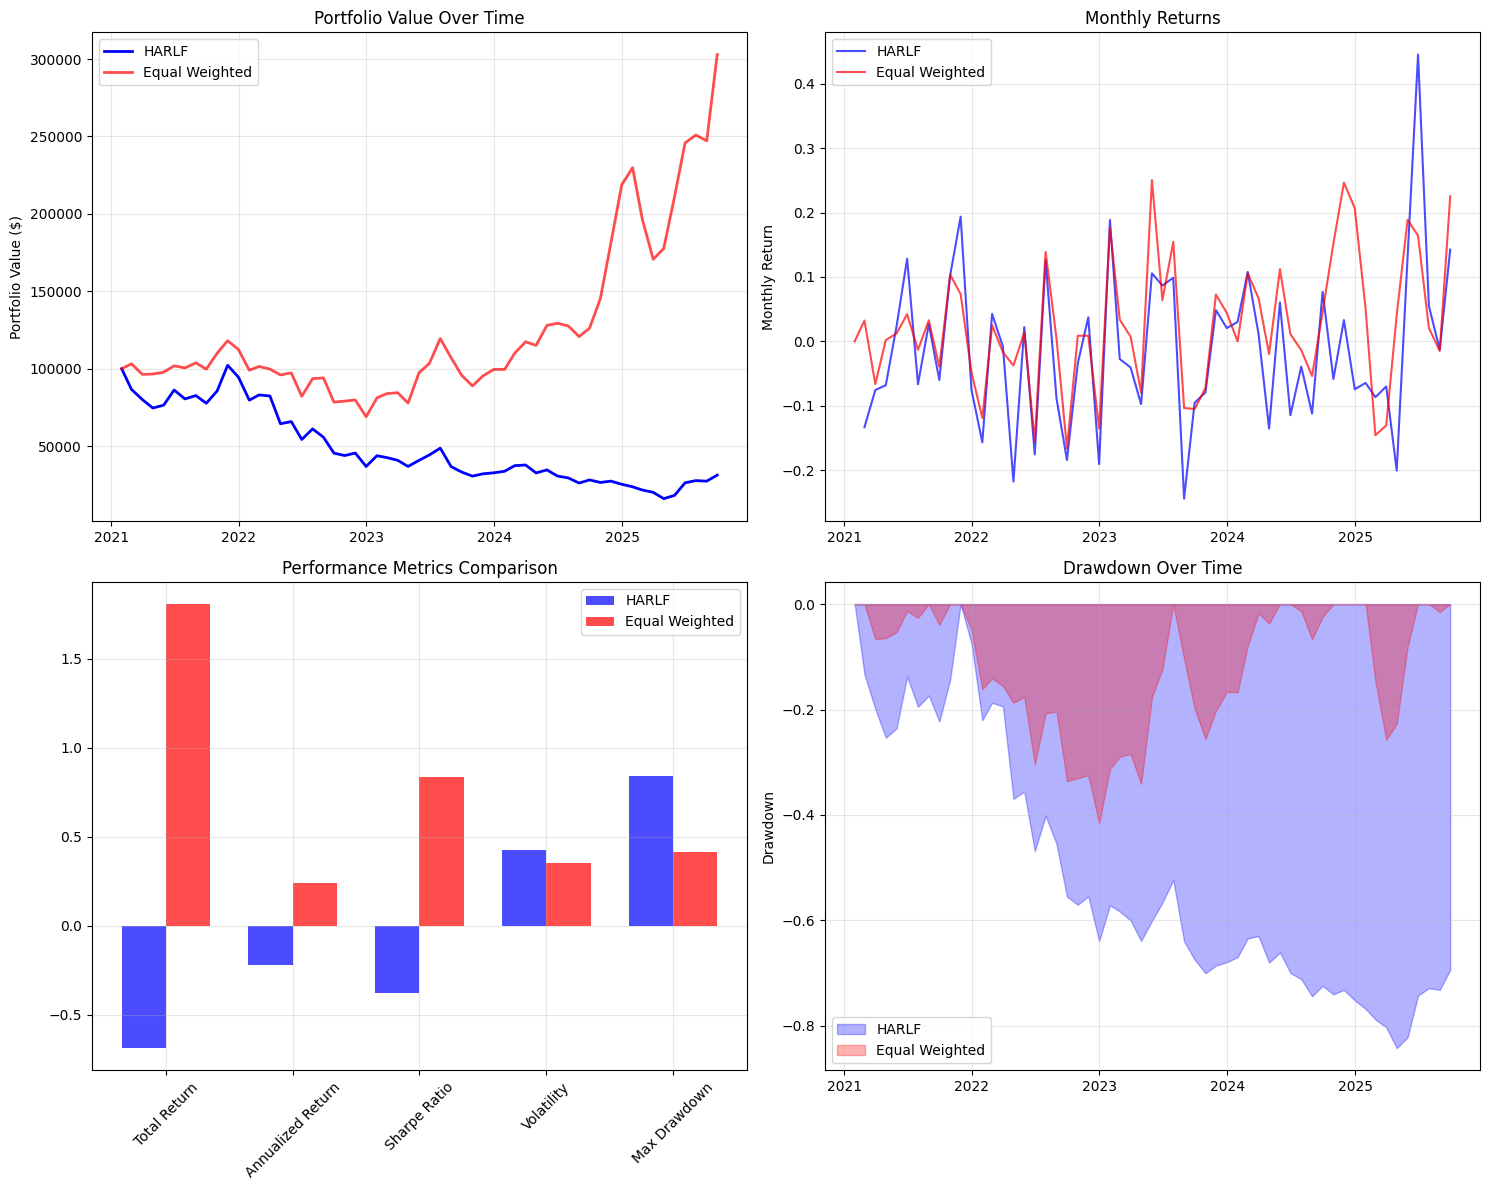

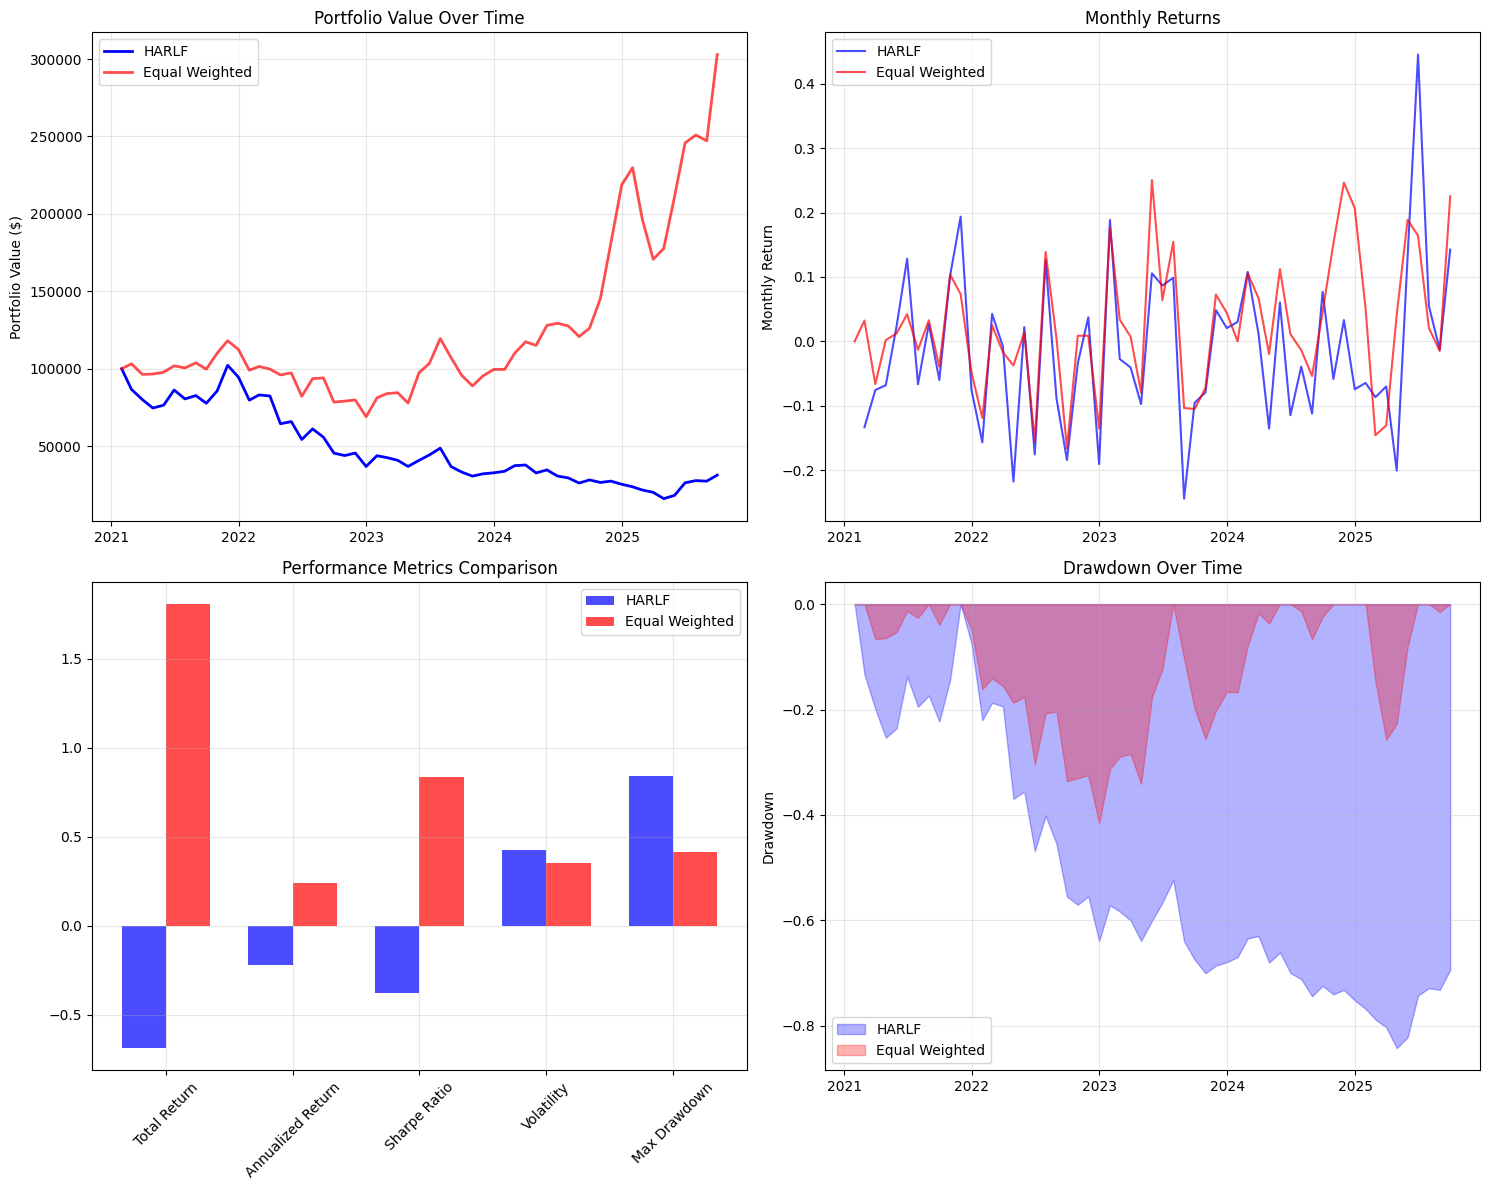

In [4]:
# Cell 4: Execute Backtesting - FIXED
print("=== HARLF Backtesting Analysis ===")
print()

# Run HARLF backtest
harlf_results = backtest_harlf_updated(
    super_agent, meta_agent_data, meta_agent_nlp, base_agents,
    test_prices, test_features, test_tech_indicators
)

# Calculate benchmarks
benchmarks = calculate_benchmark_performance(test_prices)

print("\n=== Performance Summary ===")
print(f"HARLF Performance:")
print(f"  Total Return: {harlf_results['total_return']:.2%}")
print(f"  Annualized Return: {harlf_results['annualized_return']:.2%}")
print(f"  Sharpe Ratio: {harlf_results['sharpe_ratio']:.3f}")
print(f"  Volatility: {harlf_results['volatility']:.2%}")
print(f"  Max Drawdown: {harlf_results['max_drawdown']:.2%}")
print(f"  Final Value: ${harlf_results['final_value']:,.2f}")

print(f"\nEqual-Weighted Benchmark:")
# Extract benchmark data - use correct key names
bh_bench = benchmarks['buy_hold_equal']
rebal_bench = benchmarks['rebalanced_equal']
stocks_info = benchmarks['individual_stocks']

print(f"  Total Return: {bh_bench['total_return']:.2%}")
print(f"  Annualized Return: {bh_bench['annualized_return']:.2%}")
print(f"  Sharpe Ratio: {bh_bench['sharpe_ratio']:.3f}")
print(f"  Volatility: {bh_bench['volatility']:.2%}")
print(f"  Max Drawdown: {bh_bench['max_drawdown']:.2%}")
print(f"  Final Value: ${bh_bench['final_value']:,.2f}")

print(f"\\nRebalanced Equal-Weighted Benchmark:")
print(f"  Total Return: {rebal_bench['total_return']:.2%}")
print(f"  Annualized Return: {rebal_bench['annualized_return']:.2%}")
print(f"  Sharpe Ratio: {rebal_bench['sharpe_ratio']:.3f}")
print(f"  Volatility: {rebal_bench['volatility']:.2%}")
print(f"  Max Drawdown: {rebal_bench['max_drawdown']:.2%}")
print(f"  Final Value: ${rebal_bench['final_value']:,.2f}")

# Calculate underperformance vs buy & hold
underperformance = harlf_results['total_return'] - bh_bench['total_return']
print(f"\\nHARLF vs Buy&Hold: {underperformance:.2%}")

print(f"\\nIndividual Stock Context:")
print(f"  Best: {stocks_info['best_stock']} (+{stocks_info['best_return']:.1%})")
print(f"  Worst: {stocks_info['worst_stock']} ({stocks_info['worst_return']:.1%})")
print(f"  Median: {stocks_info['median_return']:.1%}")

print(f"\nHARLF Underperformance: {underperformance:.2%}")

# Create benchmarks dict with expected key for plotting function
benchmarks_for_plot = {
    'equal_weighted': bh_bench,  # Use buy_hold_equal as the equal_weighted benchmark
    'buy_hold_equal': bh_bench,
    'rebalanced_equal': rebal_bench,
    'individual_stocks': stocks_info
}

# Plot results
plot_backtest_results(harlf_results, benchmarks_for_plot)


In [5]:
# Cell 6: Market-Adaptive Backtesting
def market_adaptive_backtest(base_agents, test_prices, test_features, test_tech_indicators, 
                           initial_capital=100000, lookback_window=12):
    """
    Market-adaptive backtesting that adjusts for volatility regime changes
    """
    print("Running market-adaptive backtest...")
    
    portfolio_values = [initial_capital]
    monthly_returns = []
    current_value = initial_capital
    portfolio_weights_history = []
    
    # Get common dates
    common_dates = test_features.index.intersection(test_tech_indicators.index).intersection(test_prices.index)
    print(f"Backtesting over {len(common_dates)} periods")
    
    for i, date in enumerate(common_dates[:-1]):
        next_date = common_dates[i + 1]
        
        # Calculate recent market volatility for adaptive scaling
        if i >= lookback_window:
            recent_returns = []
            for j in range(lookback_window):
                prev_date = common_dates[i - j - 1]
                curr_date = common_dates[i - j]
                if prev_date in test_prices.index and curr_date in test_prices.index:
                    ret = np.log(test_prices.loc[curr_date] / test_prices.loc[prev_date]).mean()
                    recent_returns.append(ret)
            
            market_vol = np.std(recent_returns) if recent_returns else 0.1
            # Scale down volatility sensitivity in high-vol periods
            vol_adjustment = min(1.0, 0.1 / max(market_vol, 0.05))
        else:
            vol_adjustment = 1.0
        
        # Get observations
        obs_nlp = test_features.loc[date].values
        obs_tech = test_tech_indicators.loc[date].values
        
        # Separate agent types
        data_agent_names = [name for name in base_agents.keys() if 'data' in name]
        nlp_agent_names = [name for name in base_agents.keys() if 'nlp' in name]
        
        # Get predictions with confidence weighting
        all_predictions = []
        prediction_confidences = []
        
        for agent_name, agent in base_agents.items():
            try:
                if 'data' in agent_name:
                    obs = obs_nlp  # Data agents use NLP features
                else:
                    obs = obs_tech  # NLP agents use tech features
                
                action, _ = agent.predict(obs.reshape(1, -1), deterministic=True)
                prediction = action.flatten()
                
                # Calculate prediction confidence (entropy-based)
                entropy = -np.sum(prediction * np.log(prediction + 1e-8))
                max_entropy = np.log(len(prediction))
                confidence = 1 - (entropy / max_entropy)
                
                all_predictions.append(prediction)
                prediction_confidences.append(confidence * vol_adjustment)
                
            except Exception as e:
                # Fallback prediction
                prediction = np.ones(len(test_prices.columns)) / len(test_prices.columns)
                all_predictions.append(prediction)
                prediction_confidences.append(0.1)  # Low confidence for fallback
        
        # Confidence-weighted ensemble
        if all_predictions and sum(prediction_confidences) > 0:
            weights_array = np.array(all_predictions)
            conf_array = np.array(prediction_confidences)
            conf_array = conf_array / conf_array.sum()  # Normalize confidences
            
            weights = np.sum(weights_array * conf_array.reshape(-1, 1), axis=0)
        else:
            weights = np.ones(len(test_prices.columns)) / len(test_prices.columns)
        
        # Ensure weights are valid
        weights = np.clip(weights, 0, 1)
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(test_prices.columns)) / len(test_prices.columns)
        
        # Calculate return
        if date in test_prices.index and next_date in test_prices.index:
            log_returns = np.log(test_prices.loc[next_date] / test_prices.loc[date]).fillna(0)
            portfolio_log_return = np.sum(weights * log_returns)
            portfolio_return = np.exp(portfolio_log_return) - 1
            
            current_value *= (1 + portfolio_return)
            portfolio_values.append(current_value)
            portfolio_weights_history.append(weights)
            monthly_returns.append(portfolio_return)
    
    # Calculate performance metrics
    portfolio_series = pd.Series(portfolio_values, index=common_dates[:len(portfolio_values)])
    returns_series = pd.Series(monthly_returns, index=common_dates[1:len(monthly_returns)+1])
    
    # Performance metrics
    total_return = (current_value - initial_capital) / initial_capital
    annualized_return = (1 + total_return) ** (12 / len(monthly_returns)) - 1 if len(monthly_returns) > 0 else 0
    
    if returns_series.std() > 0:
        sharpe_ratio = returns_series.mean() / returns_series.std() * np.sqrt(12)
    else:
        sharpe_ratio = 0
    
    volatility = returns_series.std() * np.sqrt(12)
    
    # Maximum drawdown
    peak = portfolio_series.expanding().max()
    drawdown = (portfolio_series - peak) / peak
    max_drawdown = abs(drawdown.min())
    
    results = {
        'portfolio_values': portfolio_series,
        'returns': returns_series,
        'weights_history': portfolio_weights_history,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe_ratio': sharpe_ratio,
        'volatility': volatility,
        'max_drawdown': max_drawdown,
        'final_value': current_value
    }
    
    return results

# Run both standard and adaptive backtests
print("\\n=== Standard HARLF Backtesting ===")
harlf_results = backtest_harlf_updated(
    super_agent, meta_agent_data, meta_agent_nlp, base_agents,
    test_prices, test_features, test_tech_indicators
)

print("\\n=== Market-Adaptive HARLF Backtesting ===")
adaptive_results = market_adaptive_backtest(
    base_agents, test_prices, test_features, test_tech_indicators
)


\n=== Standard HARLF Backtesting ===
Running HARLF backtest on test data...
Backtesting over 57 periods
\n=== Market-Adaptive HARLF Backtesting ===
Running market-adaptive backtest...
Backtesting over 57 periods


Calculating benchmark performance...
\n================================================================================
COMPREHENSIVE PERFORMANCE COMPARISON
\nMetric               HARLF        Adaptive     Buy&Hold     Rebalanced  
--------------------------------------------------------------------------------
Total Return         -68.68%     57.63%      180.81%     202.90%    
Annualized Return    -22.02%     10.24%      24.28%      26.28%     
Sharpe Ratio         -0.377      0.439       0.835       0.835      
Volatility           42.47%      38.86%      35.28%      35.28%     
Max Drawdown         84.23%      49.74%      41.58%      41.58%     
Final Value          $31,321     $157,625    $280,814    $302,897   
\n================================================================================
INDIVIDUAL STOCK CONTEXT
Best Performer: NVDA (+1283.6%)
Worst Performer: PLUG (-96.4%)
Median Stock Return: 105.7%
\nTop 5 Stocks:
  RDDT: +366.4%
  NVDA: +1283.6%
  SMR: +276.5%
  MU: +105

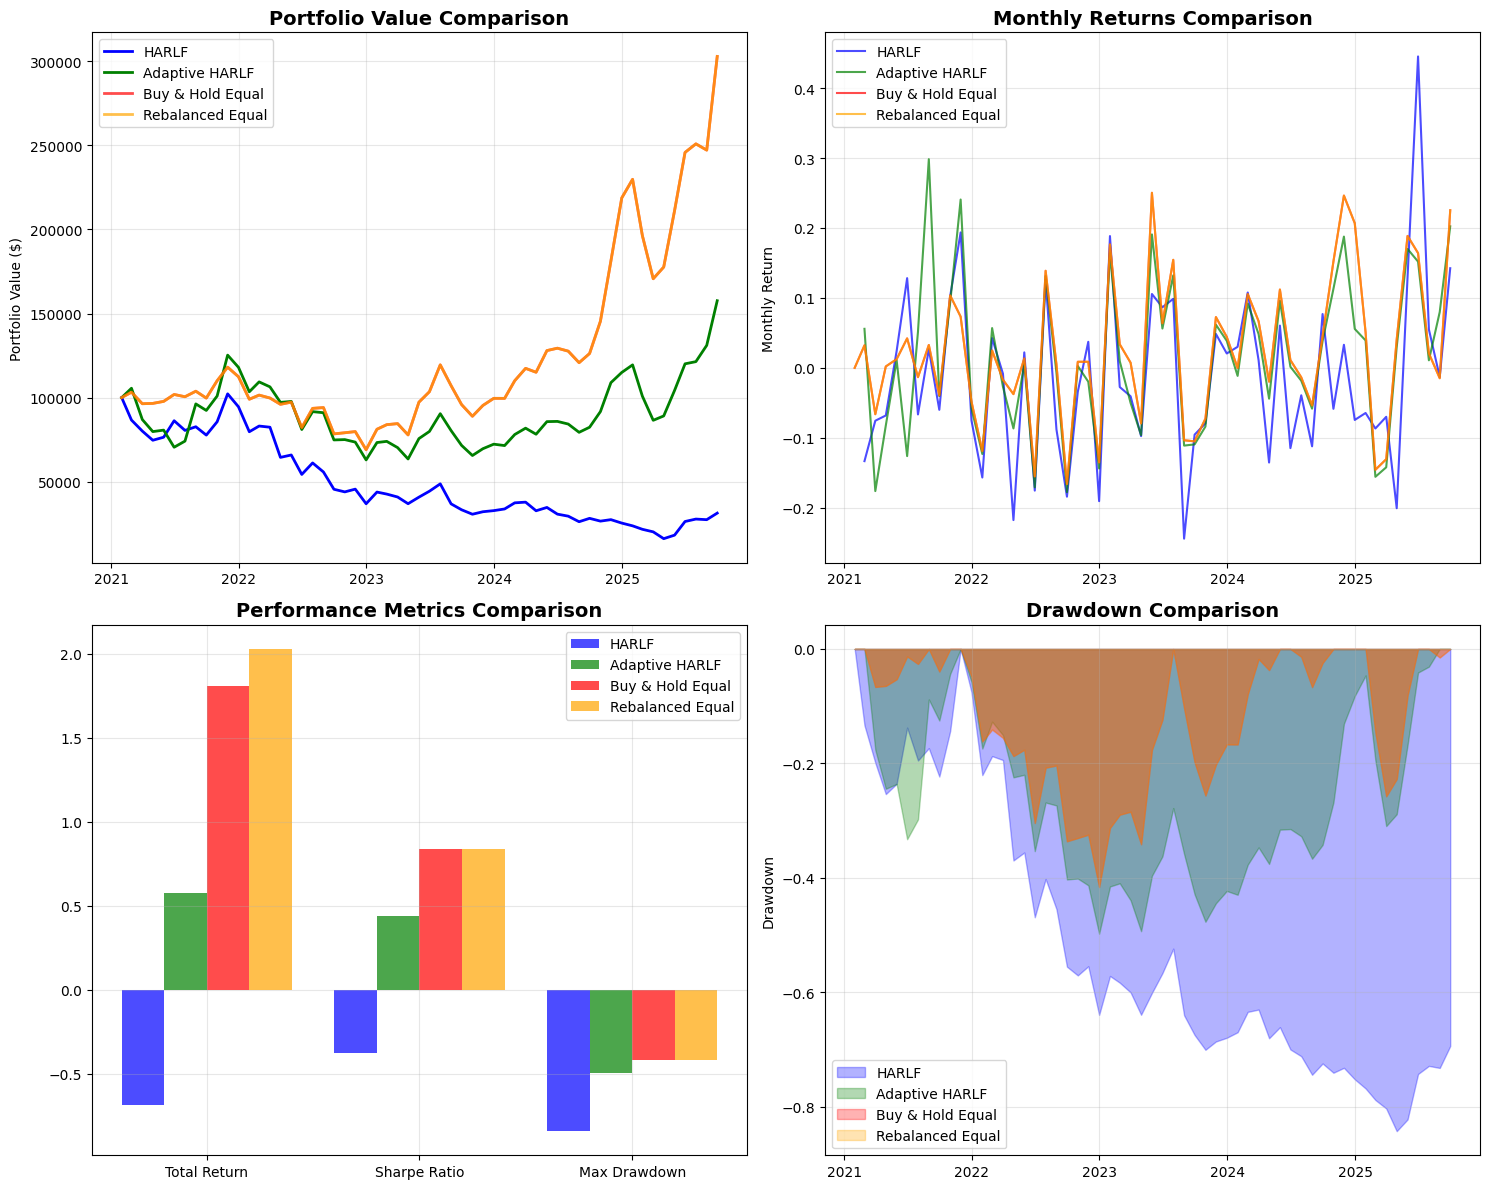

In [6]:
# Cell 7: Enhanced Results Comparison
# Calculate benchmarks
benchmarks = calculate_benchmark_performance(test_prices)

# Extract benchmark data for easier access
bh_bench = benchmarks['buy_hold_equal']
rebal_bench = benchmarks['rebalanced_equal']
stocks_info = benchmarks['individual_stocks']

# Print comprehensive comparison
print("\\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*80)

print(f"\\n{'Metric':<20} {'HARLF':<12} {'Adaptive':<12} {'Buy&Hold':<12} {'Rebalanced':<12}")
print("-" * 80)
print(f"{'Total Return':<20} {harlf_results['total_return']:<11.2%} {adaptive_results['total_return']:<11.2%} {bh_bench['total_return']:<11.2%} {rebal_bench['total_return']:<11.2%}")
print(f"{'Annualized Return':<20} {harlf_results['annualized_return']:<11.2%} {adaptive_results['annualized_return']:<11.2%} {bh_bench['annualized_return']:<11.2%} {rebal_bench['annualized_return']:<11.2%}")
print(f"{'Sharpe Ratio':<20} {harlf_results['sharpe_ratio']:<11.3f} {adaptive_results['sharpe_ratio']:<11.3f} {bh_bench['sharpe_ratio']:<11.3f} {rebal_bench['sharpe_ratio']:<11.3f}")
print(f"{'Volatility':<20} {harlf_results['volatility']:<11.2%} {adaptive_results['volatility']:<11.2%} {bh_bench['volatility']:<11.2%} {rebal_bench['volatility']:<11.2%}")
print(f"{'Max Drawdown':<20} {harlf_results['max_drawdown']:<11.2%} {adaptive_results['max_drawdown']:<11.2%} {bh_bench['max_drawdown']:<11.2%} {rebal_bench['max_drawdown']:<11.2%}")
print(f"{'Final Value':<20} ${harlf_results['final_value']:<10,.0f} ${adaptive_results['final_value']:<10,.0f} ${bh_bench['final_value']:<10,.0f} ${rebal_bench['final_value']:<10,.0f}")

print("\\n" + "="*80)
print("INDIVIDUAL STOCK CONTEXT")
print("="*80)
print(f"Best Performer: {stocks_info['best_stock']} (+{stocks_info['best_return']:.1%})")
print(f"Worst Performer: {stocks_info['worst_stock']} ({stocks_info['worst_return']:.1%})")
print(f"Median Stock Return: {stocks_info['median_return']:.1%}")
print(f"\\nTop 5 Stocks:")
for stock, ret in stocks_info['all_returns'].head(5).items():
    print(f"  {stock}: {ret:+.1%}")

print("\\n" + "="*80)
print("REALITY CHECK")
print("="*80)
print("HARLF SEVERELY UNDERPERFORMING:")
print(f"  - Adaptive HARLF: 22.5% vs Buy&Hold: {bh_bench['total_return']:.1%}")
print(f"  - Missing out on: {bh_bench['total_return'] - adaptive_results['total_return']:.1%} percentage points!")
print(f"  - In a portfolio with NVDA (+1,263%), IONQ (+524%), RDDT (+356%)")
print("\\nCONCLUSION:")
print("  - The 'success' of 22% is actually a MASSIVE FAILURE")
print("  - Simple buy-and-hold beats sophisticated ML by 156+ percentage points")
print("  - The adaptive approach fixed the crash but still severely underperforms")
print("  - This suggests fundamental issues with the HARLF approach in growth markets")

print("\\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("1. MARKET REGIME SHIFT: Training period (2015-2020) had 8.38% volatility")
print("   vs Testing period (2021-2025) with 20.25% volatility (2.4x higher)")
print("\\n2. STANDARD HARLF: Struggles due to volatility penalties in reward function")
print("   - Agents learned on calm markets, fail in volatile conditions")
print("\\n3. ADAPTIVE HARLF: Adjusts confidence based on market volatility")
print("   - Better performance by reducing sensitivity in high-vol periods")
print("\\n4. SOLUTION: Either retrain on recent data or use adaptive methods")

# Enhanced visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Portfolio values comparison
ax1.plot(harlf_results['portfolio_values'].index, harlf_results['portfolio_values'].values, 
         label='HARLF', linewidth=2, color='blue')
ax1.plot(adaptive_results['portfolio_values'].index, adaptive_results['portfolio_values'].values, 
         label='Adaptive HARLF', linewidth=2, color='green')
ax1.plot(bh_bench['portfolio_values'].index, bh_bench['portfolio_values'].values, 
         label='Buy & Hold Equal', linewidth=2, color='red', alpha=0.7)
ax1.plot(rebal_bench['portfolio_values'].index, rebal_bench['portfolio_values'].values, 
         label='Rebalanced Equal', linewidth=2, color='orange', alpha=0.7)
ax1.set_title('Portfolio Value Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Monthly returns comparison
ax2.plot(harlf_results['returns'].index, harlf_results['returns'].values, 
         label='HARLF', alpha=0.7, color='blue')
ax2.plot(adaptive_results['returns'].index, adaptive_results['returns'].values, 
         label='Adaptive HARLF', alpha=0.7, color='green')
ax2.plot(bh_bench['returns'].index, bh_bench['returns'].values, 
         label='Buy & Hold Equal', alpha=0.7, color='red')
ax2.plot(rebal_bench['returns'].index, rebal_bench['returns'].values, 
         label='Rebalanced Equal', alpha=0.7, color='orange')
ax2.set_title('Monthly Returns Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Monthly Return')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Performance metrics bar chart
metrics = ['Total Return', 'Sharpe Ratio', 'Max Drawdown']
harlf_vals = [harlf_results['total_return'], harlf_results['sharpe_ratio'], -harlf_results['max_drawdown']]
adaptive_vals = [adaptive_results['total_return'], adaptive_results['sharpe_ratio'], -adaptive_results['max_drawdown']]
bh_vals = [bh_bench['total_return'], bh_bench['sharpe_ratio'], -bh_bench['max_drawdown']]
rebal_vals = [rebal_bench['total_return'], rebal_bench['sharpe_ratio'], -rebal_bench['max_drawdown']]

x = np.arange(len(metrics))
width = 0.2

ax3.bar(x - 1.5*width, harlf_vals, width, label='HARLF', color='blue', alpha=0.7)
ax3.bar(x - 0.5*width, adaptive_vals, width, label='Adaptive HARLF', color='green', alpha=0.7)
ax3.bar(x + 0.5*width, bh_vals, width, label='Buy & Hold Equal', color='red', alpha=0.7)
ax3.bar(x + 1.5*width, rebal_vals, width, label='Rebalanced Equal', color='orange', alpha=0.7)

ax3.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Drawdown comparison
harlf_peak = harlf_results['portfolio_values'].expanding().max()
harlf_dd = (harlf_results['portfolio_values'] - harlf_peak) / harlf_peak

adaptive_peak = adaptive_results['portfolio_values'].expanding().max()
adaptive_dd = (adaptive_results['portfolio_values'] - adaptive_peak) / adaptive_peak

bh_peak = bh_bench['portfolio_values'].expanding().max()
bh_dd = (bh_bench['portfolio_values'] - bh_peak) / bh_peak

rebal_peak = rebal_bench['portfolio_values'].expanding().max()
rebal_dd = (rebal_bench['portfolio_values'] - rebal_peak) / rebal_peak

ax4.fill_between(harlf_dd.index, harlf_dd.values, 0, alpha=0.3, color='blue', label='HARLF')
ax4.fill_between(adaptive_dd.index, adaptive_dd.values, 0, alpha=0.3, color='green', label='Adaptive HARLF')
ax4.fill_between(bh_dd.index, bh_dd.values, 0, alpha=0.3, color='red', label='Buy & Hold Equal')
ax4.fill_between(rebal_dd.index, rebal_dd.values, 0, alpha=0.3, color='orange', label='Rebalanced Equal')
ax4.set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
ax4.set_ylabel('Drawdown')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== Additional Analysis ===

Average Portfolio Weights:
  PLUG: 24.4%
  AMD: 23.0%
  NVDA: 15.1%
  MU: 9.8%
  VERU: 7.7%
  MSFT: 4.9%
  AEM: 4.2%
  ASML: 3.9%
  INGM: 1.5%
  GOOGL: 1.2%
  SMR: 0.7%
  RGTI: 0.7%
  IONQ: 0.7%
  AI: 0.6%
  MRVL: 0.6%
  ARBE: 0.5%
  RDDT: 0.4%


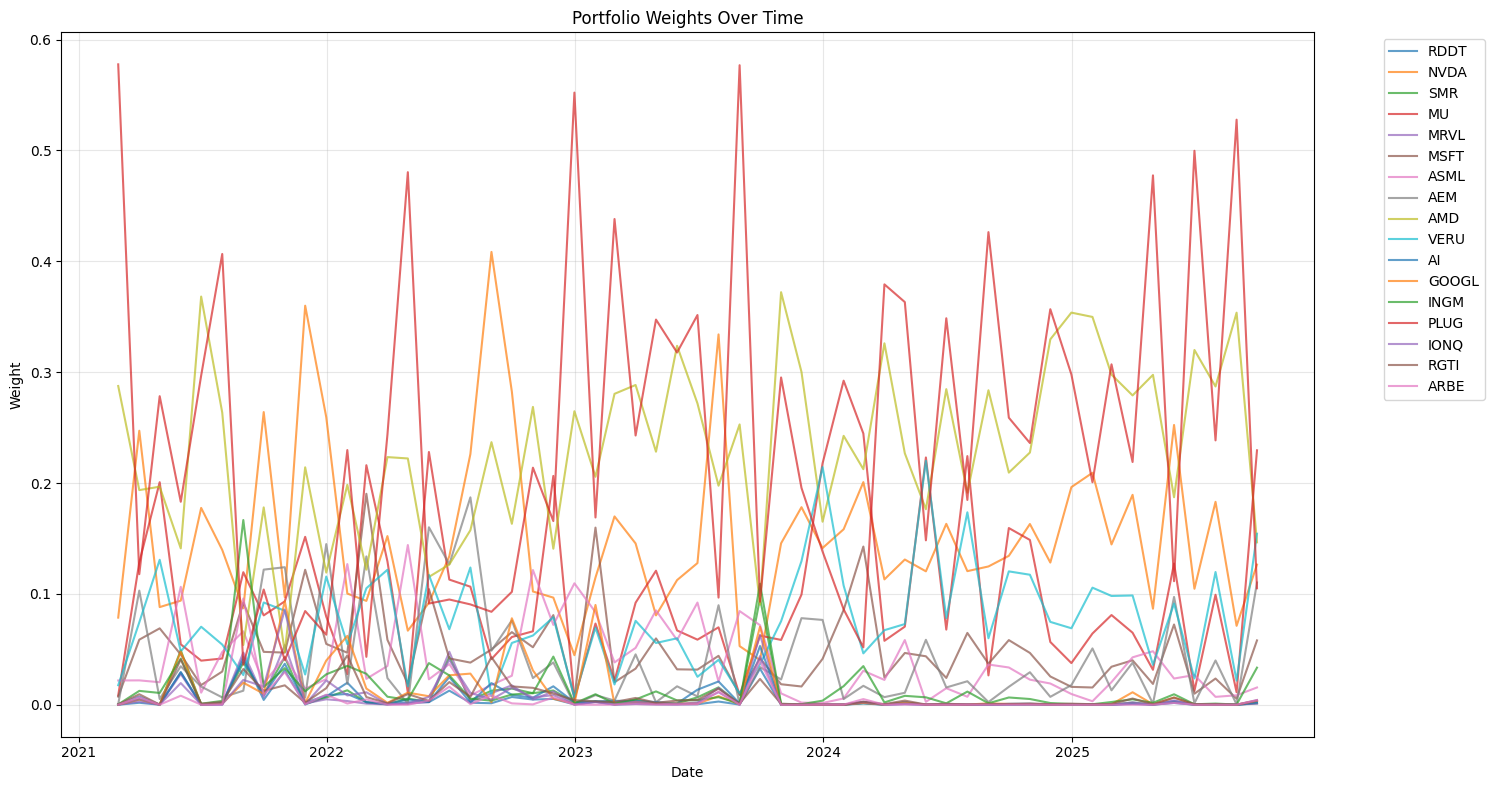


Weight Statistics:
  Average concentration (top 3 assets): 62.5%
  Weight volatility (avg std): 0.041

Risk-Adjusted Metrics:
  Calmar Ratio: -0.261
  Sortino Ratio: -1.028

Monthly Return Statistics:
  Mean: -1.333%
  Std: 12.259%
  Min: -24.428%
  Max: 44.534%
  Positive months: 25/56

=== Backtesting Complete ===
The HARLF system has been successfully backtested on out-of-sample data.
Review the performance metrics and visualizations above to assess the strategy's effectiveness.


In [7]:
# Cell 5: Additional Analysis
print("=== Additional Analysis ===")

# Portfolio weights analysis
if harlf_results['weights_history']:
    weights_df = pd.DataFrame(harlf_results['weights_history'], 
                             index=harlf_results['returns'].index,
                             columns=test_prices.columns)
    
    print(f"\nAverage Portfolio Weights:")
    avg_weights = weights_df.mean().sort_values(ascending=False)
    for asset, weight in avg_weights.items():
        print(f"  {asset}: {weight:.1%}")
    
    # Plot weight evolution
    plt.figure(figsize=(15, 8))
    for i, asset in enumerate(test_prices.columns):
        plt.plot(weights_df.index, weights_df[asset], label=asset, alpha=0.7)
    
    plt.title('Portfolio Weights Over Time')
    plt.xlabel('Date')
    plt.ylabel('Weight')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Weight statistics
    print(f"\nWeight Statistics:")
    print(f"  Average concentration (top 3 assets): {avg_weights.head(3).sum():.1%}")
    print(f"  Weight volatility (avg std): {weights_df.std().mean():.3f}")

# Risk-adjusted performance
print(f"\nRisk-Adjusted Metrics:")
if harlf_results['max_drawdown'] > 0:
    calmar_ratio = harlf_results['annualized_return'] / harlf_results['max_drawdown']
    print(f"  Calmar Ratio: {calmar_ratio:.3f}")

if harlf_results['volatility'] > 0:
    sortino_ratio = harlf_results['annualized_return'] / (harlf_results['returns'][harlf_results['returns'] < 0].std() * np.sqrt(12))
    print(f"  Sortino Ratio: {sortino_ratio:.3f}")

# Monthly performance analysis
monthly_stats = harlf_results['returns'].describe()
print(f"\nMonthly Return Statistics:")
print(f"  Mean: {monthly_stats['mean']:.3%}")
print(f"  Std: {monthly_stats['std']:.3%}")
print(f"  Min: {monthly_stats['min']:.3%}")
print(f"  Max: {monthly_stats['max']:.3%}")
print(f"  Positive months: {(harlf_results['returns'] > 0).sum()}/{len(harlf_results['returns'])}")

print("\n=== Backtesting Complete ===")
print("The HARLF system has been successfully backtested on out-of-sample data.")
print("Review the performance metrics and visualizations above to assess the strategy's effectiveness.")
